In [59]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, confusion_matrix, auc, roc_auc_score, average_precision_score

In [60]:
transaction_data = pd.read_csv('./input/transaction.csv')
identity_data = pd.read_csv('./input/identity.csv')
data = transaction_data.merge(identity_data, on='TransactionID', how='left')
data['has_identity'] = identity_data['TransactionID'].isin(data['TransactionID']).astype('uint8')
data['has_identity'] = data['TransactionID'].isin(identity_data['TransactionID']).astype('uint8')

In [61]:
missing_percentages = data.isna().mean()
missing_percentages.sort_values(ascending=False).head(20)

proxy_type            0.991247
dist2                 0.936284
screen_resolution     0.875895
os                    0.868654
screen_color_depth    0.868619
match_status          0.868248
timezone_offset       0.864456
DeviceInfo            0.799055
R_emaildomain         0.767516
browser               0.762451
DeviceType            0.761557
dist1                 0.596524
P_emaildomain         0.159949
addr2                 0.111264
addr1                 0.111264
card2                 0.015127
card5                 0.007212
card4                 0.002670
card6                 0.002660
card3                 0.002650
dtype: float64

In [ ]:
MISSING_THRESHOLD = 0.75
missing_percentages = data.isna().mean()

for column in data.columns:
    data[f'{column}_was_missing'] = data[column].isna().astype('uint8')

columns_to_drop = missing_percentages[missing_percentages >= MISSING_THRESHOLD].index
data = data.drop(columns=columns_to_drop)

missing_percentages = data.isna().mean()

columns_to_fill = missing_percentages[missing_percentages > 0].index
numerical_columns = [column for column in columns_to_fill if data[column].dtype != 'object']
categorical_columns = [column for column in columns_to_fill if data[column].dtype == 'object']

data[numerical_columns] = data[numerical_columns].fillna(data[numerical_columns].median())
data[categorical_columns] = data[categorical_columns].fillna(data[categorical_columns].mode().iloc[0])
data.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,timezone_offset_was_missing,proxy_type_was_missing,os_was_missing,browser_was_missing,screen_color_depth_was_missing,screen_resolution_was_missing,match_status_was_missing,DeviceType_was_missing,DeviceInfo_was_missing,has_identity_was_missing
0,2987000,0,86400,68.5,W,13926,361.0,150.0,discover,142.0,...,1,1,1,1,1,1,1,1,1,0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,1,1,1,1,1,1,1,1,1,0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,1,1,1,1,1,1,1,1,1,0
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,1,1,1,1,1,1,1,1,1,0
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0,1,0,0,0,0,0,0,0,0


In [63]:
object_columns = data.select_dtypes(include=['object']).columns
data = pd.get_dummies(data, columns=object_columns, drop_first=True, dtype='uint8')
data.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,P_emaildomain_web.de,P_emaildomain_windstream.net,P_emaildomain_yahoo.co.jp,P_emaildomain_yahoo.co.uk,P_emaildomain_yahoo.com,P_emaildomain_yahoo.com.mx,P_emaildomain_yahoo.de,P_emaildomain_yahoo.es,P_emaildomain_yahoo.fr,P_emaildomain_ymail.com
0,2987000,0,86400,68.5,13926,361.0,150.0,142.0,315.0,87.0,...,0,0,0,0,0,0,0,0,0,0
1,2987001,0,86401,29.0,2755,404.0,150.0,102.0,325.0,87.0,...,0,0,0,0,0,0,0,0,0,0
2,2987002,0,86469,59.0,4663,490.0,150.0,166.0,330.0,87.0,...,0,0,0,0,0,0,0,0,0,0
3,2987003,0,86499,50.0,18132,567.0,150.0,117.0,476.0,87.0,...,0,0,0,0,1,0,0,0,0,0
4,2987004,0,86506,50.0,4497,514.0,150.0,102.0,420.0,87.0,...,0,0,0,0,0,0,0,0,0,0


In [64]:
x = data.drop('isFraud', axis=1)
y = data['isFraud']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [65]:
num_not_fraud = (y_train == 0).sum()
num_fraud = (y_train == 1).sum()
scale = num_not_fraud / num_fraud

model = xgb.XGBClassifier(
    n_estimators=50_000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    scale_pos_weight=scale,
    eval_metric='aucpr',
    early_stopping_rounds=1_000,
    random_state=42,
    device='cuda'
)

model.fit(x_train, y_train, eval_set=[(x_test, y_test)], verbose=1_000)
print(f'\nBest iteration: {model.best_iteration}')

[0]	validation_0-aucpr:0.17331
[1000]	validation_0-aucpr:0.41019
[2000]	validation_0-aucpr:0.51185
[3000]	validation_0-aucpr:0.58023
[4000]	validation_0-aucpr:0.62493
[5000]	validation_0-aucpr:0.65441
[6000]	validation_0-aucpr:0.67632
[7000]	validation_0-aucpr:0.69314
[8000]	validation_0-aucpr:0.70425
[9000]	validation_0-aucpr:0.71363
[10000]	validation_0-aucpr:0.72044
[11000]	validation_0-aucpr:0.72687
[12000]	validation_0-aucpr:0.73054
[13000]	validation_0-aucpr:0.73350
[14000]	validation_0-aucpr:0.73556
[15000]	validation_0-aucpr:0.73783
[16000]	validation_0-aucpr:0.73998
[17000]	validation_0-aucpr:0.74101
[18000]	validation_0-aucpr:0.74218
[19000]	validation_0-aucpr:0.74303
[20000]	validation_0-aucpr:0.74333
[21000]	validation_0-aucpr:0.74394
[22000]	validation_0-aucpr:0.74415
[23000]	validation_0-aucpr:0.74433
[24000]	validation_0-aucpr:0.74434
[25000]	validation_0-aucpr:0.74448
[25827]	validation_0-aucpr:0.74458

Best iteration: 24827


In [69]:
y_prob = model.predict_proba(x_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
precision_recall_auc = average_precision_score(y_test, y_prob)
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'PR-AUC: {precision_recall_auc:.4f}')

TARGET_RECALL = 0.80
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob)

above_target = recall_vals[:-1] >= TARGET_RECALL
if above_target.any():
    best_threshold = thresholds[above_target][precision_vals[:-1][above_target].argmax()]
else:
    f1_vals = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (precision_vals[:-1] + recall_vals[:-1] + 1e-9)
    best_threshold = thresholds[f1_vals.argmax()]

print(f'\nThreshold (targeting ≥{TARGET_RECALL*100:.0f}% recall): {best_threshold:.4f}')
predictions = (y_prob >= best_threshold).astype(int)

ROC-AUC: 0.9496
PR-AUC: 0.7447

Threshold (targeting ≥80% recall): 0.1365


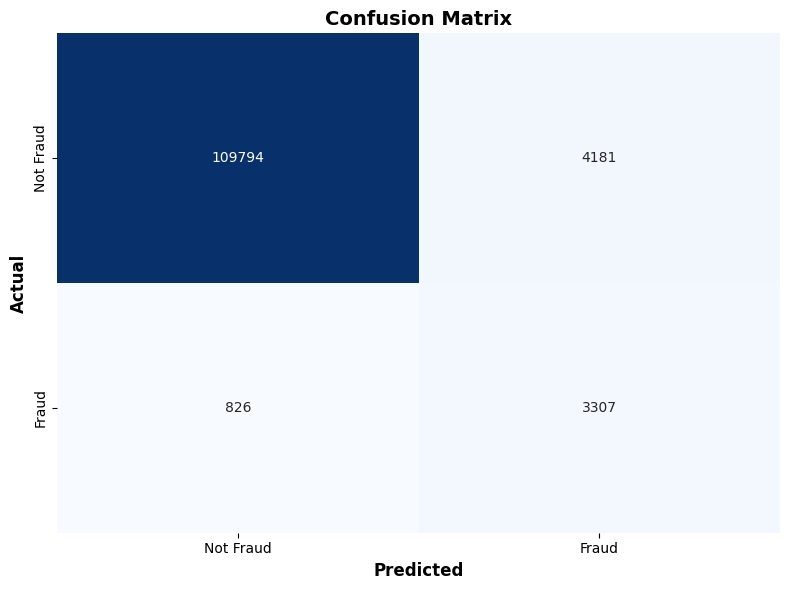

True Negatives: 109794
False Positives: 4181
False Negatives: 826
True Positives: 3307

Sensitivity (Recall): 0.8001
Specificity: 0.9633
Precision: 0.4416
Accuracy: 0.9576
F1 Score: 0.5691


In [70]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_xlabel("Predicted", fontsize=12, fontweight="bold")
    ax.set_ylabel("Actual", fontsize=12, fontweight="bold")
    ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    true_negative_val, false_positive_val, false_negative_val, true_positive_val = cm.ravel()
    sensitivity = true_positive_val / (true_positive_val + false_negative_val)
    specificity = true_negative_val / (true_negative_val + false_positive_val)
    precision = true_positive_val / (true_positive_val + false_positive_val)
    accuracy = (true_positive_val + true_negative_val) / (true_positive_val + true_negative_val + false_positive_val + false_negative_val)
    f1_score = 2 * ((precision * sensitivity) / (precision + sensitivity))

    print(f"True Negatives: {true_negative_val}")
    print(f"False Positives: {false_positive_val}")
    print(f"False Negatives: {false_negative_val}")
    print(f"True Positives: {true_positive_val}")
    print(f"\nSensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1_score:.4f}")

plot_confusion_matrix(y_test, predictions, class_names=['Not Fraud', 'Fraud'])

In [ ]:
def plot_precision_recall_curve(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    precision_recall_auc = auc(recall, precision)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(recall, precision, color="#3498db", lw=2, label=f"Precision-Recall curve (AUC = {precision_recall_auc:.4f})")
    ax.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random Classifier")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("Recall", fontsize=12, fontweight="bold")
    ax.set_ylabel("Precision", fontsize=12, fontweight="bold")
    ax.set_title("Precision-Recall Curve", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right", fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_precision_recall_curve(y_test, model.predict_proba(x_test)[:, 1])